<a href="https://colab.research.google.com/github/Winicius-dos-Passos/previsao-ur-vmd-bilstm/blob/main/BiLSTM_Forecasting_UR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalação das bibliotecass
!pip install tensorflow scikit-learn -q

In [ ]:
# Imports das bibliotecas
import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# Reprodutibilidade randômica
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Sementes globais
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

tf.config.experimental.enable_op_determinism()

# Configuração de Mixed Precision
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print('Mixed Precision ativado (GPU otimizada).')
except Exception as e:
    print('Mixed Precision não ativado (Rodando em float32).')

Mixed Precision ativado (GPU otimizada).


In [ ]:
# Carregamento dos dados
url_df = 'https://docs.google.com/spreadsheets/d/1MRqHSHxVjynI_0OFkbT18MiPGZ6p0t7b/export?format=xlsx'
df = pd.read_excel(url_df)
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True)
df = df.drop(columns=['Qualidade_dado', 'Cidade'])
display(df)

,Data,Tmax (°C),Tmin (°C),UR (%),U2 (m/s),Rs (MJ/m²d),Chuva (mm),Pres (kPa)
0,2007-01-01,23.90,17.70,83.50,2.483333,10.7926,8.2,90.290
1,2007-01-01,23.60,17.90,81.00,3.162500,12.9870,0.2,91.150
2,2007-01-01,22.00,16.20,85.00,4.050000,13.1611,0.6,88.040
3,2007-01-01,26.00,18.40,81.50,2.112500,15.9923,1.2,92.250
4,2007-01-02,25.50,18.80,82.50,1.550000,12.1713,18.0,90.235
...,...,...,...,...,...,...,...,...
34327,2023-12-31,22.20,16.20,82.50,2.629167,12.5924,1.0,91.340
34328,2023-12-31,24.70,14.30,64.50,2.358333,21.8447,0.8,88.170
34329,2023-12-31,27.67,17.22,73.28,0.930000,0.0000,0.0,92.010
34330,2023-12-31,28.30,16.00,71.00,2.195833,28.6827,0.0,91.390


In [ ]:
# Funções Auxiliares
def create_sequences(X, y, look_back):
  """
  Cria sequências de entrada para o modelo BiLSTM.
  """
  Xs, ys = [], []
  for i in range(len(X) - look_back):
    Xs.append(X[i:(i + look_back)])
    ys.append(y[i + look_back])
  return np.array(Xs), np.array(ys)

def avaliar_modelo(observados, estimados):
    """
    Métricas para avaliar o Modelo: RMSE, MAE, R², Willmott (d) e MBE (erro médio de vies).
    """
    obs = np.asarray(observados).reshape(-1)
    est = np.asarray(estimados).reshape(-1)
    # Índice de Concordância Willmott
    num = np.sum((est - obs) ** 2)
    den = np.sum((np.abs(est - np.mean(obs)) + np.abs(obs - np.mean(obs)))** 2)
    d = 1 - (num / den)
    # Demais métricas
    rmse = np.sqrt(mean_squared_error(obs, est))
    mae = mean_absolute_error(obs, est)
    r2 = r2_score(obs, est)
    vies = np.mean(est - obs)
    return {
        "RMSE": round(rmse, 4),
        "R²": round(r2, 4),
        "MAE": round(mae, 4),
        "Willmott": round (d, 4),
        "MBE": round(vies, 4)
        }

def gerar_features(df, alvo):
  """
  Engenharia de Features
  """

  df_feat = df.copy().reset_index(drop=True)

  # Sazonalidade Anual
  df_feat['dia_ano'] = df_feat['Data'].dt.day_of_year
  df_feat['sin_ano'] = np.sin(2 * np.pi * df_feat['dia_ano'] / 365.25)
  df_feat['cos_ano'] = np.cos(2 * np.pi * df_feat['dia_ano'] / 365.25)

  # Remover colunas auxiliares
  return df_feat.drop(columns=['Data','dia_ano'])

In [ ]:
# Configurações e variavéis alvo

variaveis_alvo = [
    'UR (%)'
]

HIPERPARAMETROS_OTIMIZADOS = {
    'UR (%)': {'look_back': 45, 'lr': 0.007, 'dropout': 0.14, 'l2_reg': 0.0004,
               'lstm_units_1': 128, 'lstm_units_2': 32, 'batch_size': 128},
}


▶ Treinamento para: UR (%)
Epoch 1/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 95s 378ms/step - loss: 0.7871 - val_loss: 0.7349 - learning_rate: 0.0070
Epoch 2/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 76s 352ms/step - loss: 0.6725 - val_loss: 0.6706 - learning_rate: 0.0070
Epoch 3/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 75s 349ms/step - loss: 0.6125 - val_loss: 0.5909 - learning_rate: 0.0070
Epoch 4/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 75s 349ms/step - loss: 0.5956 - val_loss: 0.6085 - learning_rate: 0.0070
Epoch 5/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 74s 344ms/step - loss: 0.5864 - val_loss: 0.6232 - learning_rate: 0.0070
Epoch 6/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 75s 350ms/step - loss: 0.5937 - val_loss: 0.5783 - learning_rate: 0.0070
Epoch 7/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 76s 356ms/step - loss: 0.5838 - val_loss: 0.5894 - learning_rate: 0.0070
Epoch 8/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 74s 344ms/step - loss: 0.5820 - val_loss: 0.5858 - learning_rate: 0.0070
Epoch 9/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 75s 349ms/step - lo

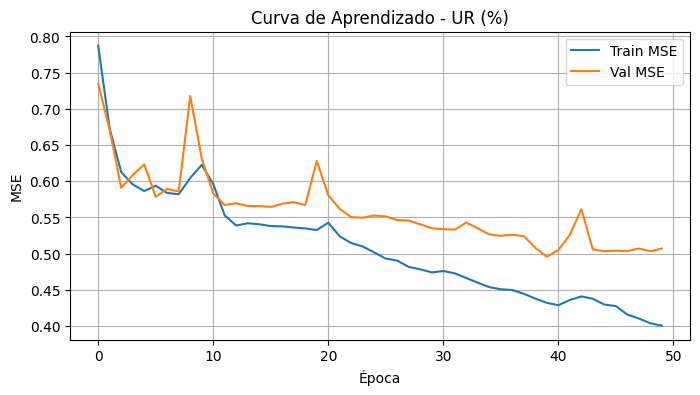


Resultados para UR (%):
RMSE: 7.9704
R²: 0.42
Willmott: 0.7775
------------------------------------------------------------


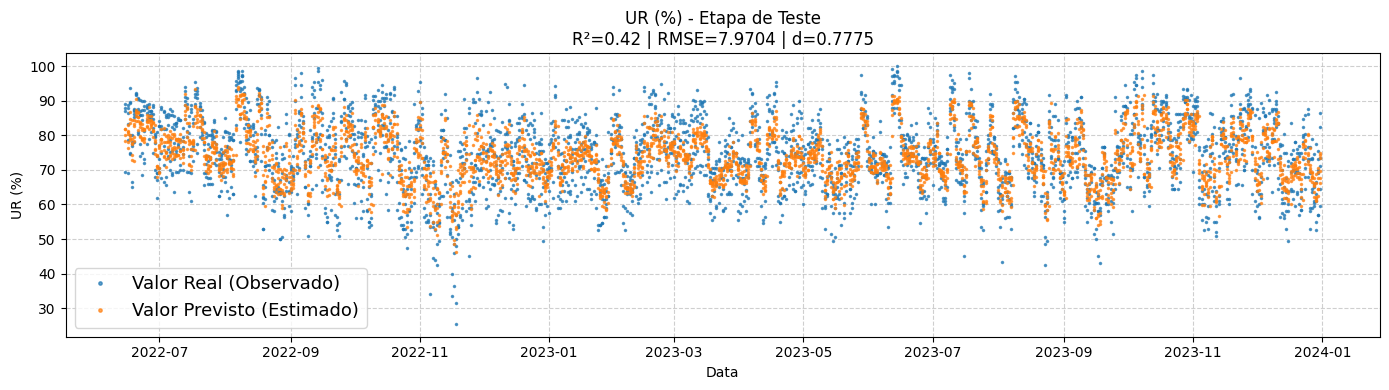

In [ ]:
resultados_metricas = []

# Loop principal
for var in variaveis_alvo:
  print('\n' + '=' * 60)
  print(f"▶ Treinamento para: {var}")
  print('=' * 60)

  df_model = df.copy()

  # Carregar hiperparâmetros
  parametros = HIPERPARAMETROS_OTIMIZADOS[var]
  look_back = parametros['look_back']
  lr = parametros['lr']
  dropout = parametros['dropout']
  l2_reg = parametros['l2_reg']
  lstm_units_1 = parametros['lstm_units_1']
  lstm_units_2 = parametros['lstm_units_2']
  batch_size = parametros['batch_size']

  # Gerar Features
  df_feat = gerar_features(df_model, var)

  # Dataframe somente com o histórico da variavel + features
  df_feat = df_feat[[var, 'sin_ano', 'cos_ano']]

  # Dividir X e y antes de escalar
  y_raw = df_feat[[var]].values
  X_raw = df_feat.values

  # Split Temporal: train / val / test
  n = len(X_raw)
  n_test = int(np.floor(n * 0.1))
  n_val = int(np.floor(n * 0.1))
  n_train = n - n_val - n_test

  train_end = n_train
  val_end = n_train + n_val

  # Fatiamento temporal estrito
  X_train = X_raw[:train_end]
  y_train = y_raw[:train_end]

  X_val = X_raw[train_end:val_end]
  y_val = y_raw[train_end:val_end]

  X_test = X_raw[val_end:]
  y_test = y_raw[val_end:]

  # Normalização dos Dados
  scaler_X = StandardScaler()
  scaler_y = StandardScaler()

  # FIT
  X_train_scaled = scaler_X.fit_transform(X_train)
  y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

  X_val_scaled = scaler_X.transform(X_val)
  y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))

  X_test_scaled = scaler_X.transform(X_test)
  y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

  # Transformar em 3D
  X_lstm_train, y_lstm_train = create_sequences(X_train_scaled, y_train_scaled, look_back)
  X_lstm_val, y_lstm_val = create_sequences(X_val_scaled, y_val_scaled, look_back)
  X_lstm_test, y_lstm_test = create_sequences(X_test_scaled, y_test_scaled, look_back)

  del df_feat, X_raw, y_raw, X_train, y_train, X_val, y_val, X_test, y_test
  del X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled
  gc.collect()
  tf.keras.backend.clear_session()

  # Construção do Modelo
  model = Sequential([
      Input(shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])),
      Bidirectional(LSTM(lstm_units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))),
      Dropout(dropout),
      Bidirectional(LSTM(lstm_units_2, return_sequences=False, kernel_regularizer=l2(l2_reg))),
      Dropout(dropout),
      Dense(1, dtype='float32')
      ])

  model.compile(optimizer=Adam(learning_rate=lr), loss='MSE')

  # Callbacks
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
  ]

  # Treinamento
  hist = model.fit(
      X_lstm_train, y_lstm_train,
      epochs=200, batch_size=batch_size,
      validation_data=(X_lstm_val, y_lstm_val),
      callbacks=callbacks, verbose=1, shuffle=False
      )

  # Curva de Aprendizado
  plt.figure(figsize=(8, 4))
  plt.plot(hist.history['loss'], label='Train MSE')
  plt.plot(hist.history['val_loss'], label='Val MSE')
  plt.title(f"Curva de Aprendizado - {var}")
  plt.xlabel('Época')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

  # --- Avaliação e Plotagem ---

  # Previsão
  y_pred_scaled = model.predict(X_lstm_test, verbose=0)

  # Inversão da Escala
  y_real = scaler_y.inverse_transform(y_lstm_test)
  y_pred = scaler_y.inverse_transform(y_pred_scaled)

  # Sem valores negativos
  if var == 'U2 (m/s)' or var == 'Rs (MJ/m²d)':
    y_pred = np.maximum(y_pred, 0)

  # Métricas
  metricas = avaliar_modelo(y_real, y_pred)
  metricas['Variavel'] = var
  resultados_metricas.append(metricas)

  # Print das métricas
  print(f"\nResultados para {var}:")
  print(f"RMSE: {metricas['RMSE']}")
  print(f"R²: {metricas['R²']}")
  print(f"Willmott: {metricas['Willmott']}")
  print('-' * 60)

  # Gráfico de Série Temporal
  dates_plot = df_model['Data'].iloc[-len(y_real):].values

  plt.figure(figsize=(14, 4))
  plt.plot(dates_plot, y_real, '.', label='Valor Real (Observado)', alpha=0.7, markersize=3)
  plt.plot(dates_plot, y_pred, '.', label='Valor Previsto (Estimado)', alpha=0.7, markersize=3)
  plt.title(f"{var} - Etapa de Teste\nR²={metricas['R²']} | RMSE={metricas['RMSE']} | d={metricas['Willmott']}")
  plt.xlabel('Data')
  plt.ylabel(var)
  plt.legend(fontsize=13, loc='best', markerscale=1.6)
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

  # Limpeza final da iteração
  del model, y_real, y_pred , dates_plot
  tf.keras.backend.clear_session()
  gc.collect()

In [ ]:
  # Criar DataFrame final com todos os resultados
  df_resultados = pd.DataFrame(resultados_metricas)
  print("\n=== RESUMO GERAL  ===")
  display(df_resultados)


=== RESUMO GERAL  ===


,RMSE,R²,MAE,Willmott,MBE,Variavel
0,7.9704,0.42,6.3249,0.7775,-0.5483,UR (%)
